Aap sab ko *Classification Assignment* diya ja raha hai. Is assignment ka objective data preprocessing aur classification model develop karna hai.

### Assignment Requirements

* Dataset ko properly analyze karein.
* Missing values ko handle karein (agar available hon).
* Required encoding perform karein (agar zarurat ho).
* Feature Scaling apply karein (agar required ho).
* Agar dataset imbalanced ho to usay Balanced Dataset mein convert karein.
* Different Classification Models apply karein aur unki performance compare karein.
* Accuracy, Precision, Recall, F1-Score, Classification Report aur Confusion Matrix generate karein.
* Best performing model select karein.
* Hyperparameter Tuning karke model ki performance improve karein.
* Model ki accuracy ko maximum possible level tak optimize karne ki koshish karein.
* Har step ki proper explanation aur code comments bhi include karein.

### Dataset: heart_failure_clinical_records_dataset.csv (Heart Failure - Death Event)

In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
# Basic info - column names, data types, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [4]:
# Summary statistics
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [5]:
# Check for missing values
df.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

This dataset has no missing values, so no cleaning is needed for that step.

In [6]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Encoding
All columns in this dataset are already numeric (0/1 flags or numbers), so no encoding is required here.

### EDA - Target Variable (DEATH_EVENT)

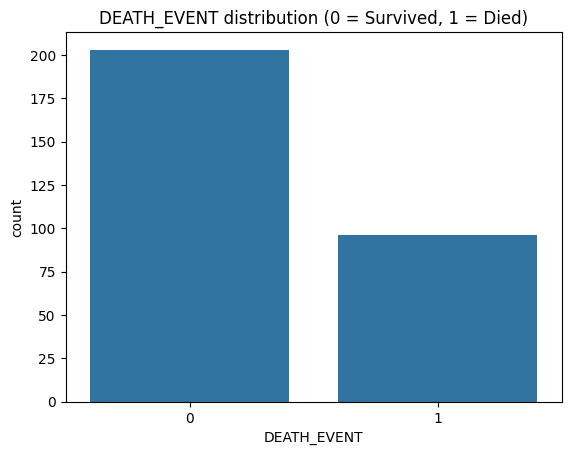

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

In [7]:
sns.countplot(x='DEATH_EVENT', data=df)
plt.title('DEATH_EVENT distribution (0 = Survived, 1 = Died)')
plt.show()

df['DEATH_EVENT'].value_counts()

The target is somewhat imbalanced (more 0s than 1s). This will be handled using SMOTE before training the models.

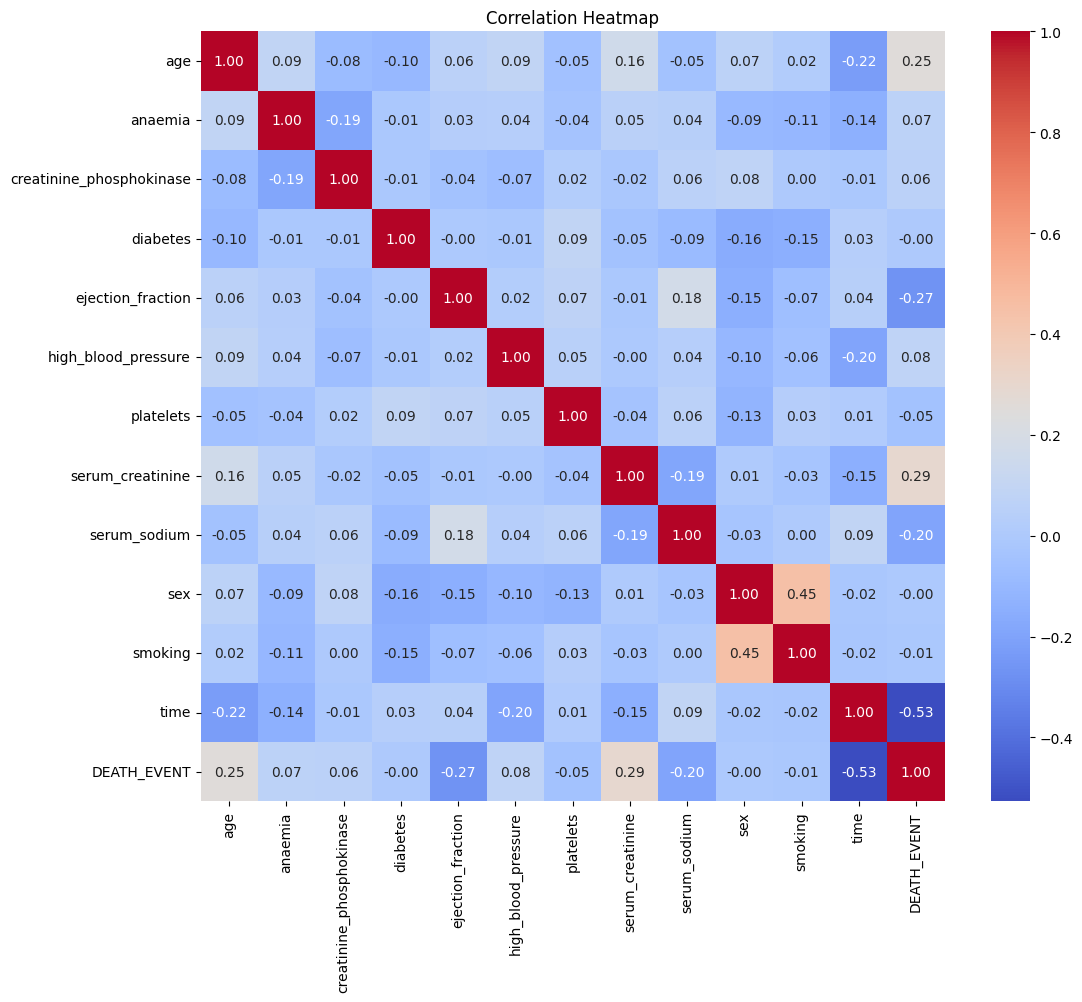

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Feature and Target Selection

In [9]:
# Target: what we are predicting
y = df['DEATH_EVENT']

# Features: everything else
X = df.drop(columns=['DEATH_EVENT'])

print(X.shape, y.shape)

(299, 12) (299,)


### Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((239, 12), (60, 12))

### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Handling Imbalanced Dataset
SMOTE (Synthetic Minority Oversampling Technique) is used to balance the training data. This is only applied to the training set, not the test set, so we evaluate on real, untouched data.

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', pd.Series(y_train_balanced).value_counts().to_dict())

Before SMOTE: {0: 162, 1: 77}
After SMOTE: {0: 162, 1: 162}


### Train Multiple Classification Models and Compare

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Dictionary of models we want to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f'{name} -> Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}')
    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

Logistic Regression -> Accuracy: 0.8000, Precision: 0.7333, Recall: 0.5789, F1: 0.6471
Decision Tree -> Accuracy: 0.7833, Precision: 0.6250, Recall: 0.7895, F1: 0.6977
Random Forest -> Accuracy: 0.8167, Precision: 0.7222, Recall: 0.6842, F1: 0.7027
KNN -> Accuracy: 0.7500, Precision: 0.6111, Recall: 0.5789, F1: 0.5946


In [14]:
# Put results in a table, sorted by F1 score
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.816667,0.722222,0.684211,0.702703
1,Decision Tree,0.783333,0.625000,0.789474,0.697674
0,Logistic Regression,0.800000,0.733333,0.578947,0.647059
3,KNN,0.750000,0.611111,0.578947,0.594595


### Best Model - Detailed Report

In [15]:
# Random Forest is picked as the best performer based on the comparison table above
best_model_initial = RandomForestClassifier(random_state=42)
best_model_initial.fit(X_train_balanced, y_train_balanced)
y_pred_rf = best_model_initial.predict(X_test_scaled)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60



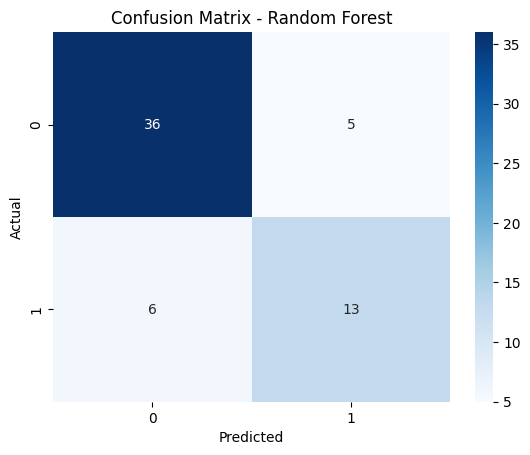

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### Hyperparameter Tuning (Random Forest)

In [17]:
from sklearn.model_selection import GridSearchCV

# A small grid of values to try, keeping it simple
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_balanced, y_train_balanced)

print('Best parameters:', grid_search.best_params_)

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [18]:
# Evaluate the tuned model on the test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f'Tuned Random Forest -> Accuracy: {acc_best:.4f}, Precision: {prec_best:.4f}, Recall: {rec_best:.4f}, F1: {f1_best:.4f}')
print()
print(classification_report(y_test, y_pred_best))

Tuned Random Forest -> Accuracy: 0.8000, Precision: 0.6842, Recall: 0.6842, F1: 0.6842

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        41
           1       0.68      0.68      0.68        19

    accuracy                           0.80        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.80      0.80      0.80        60



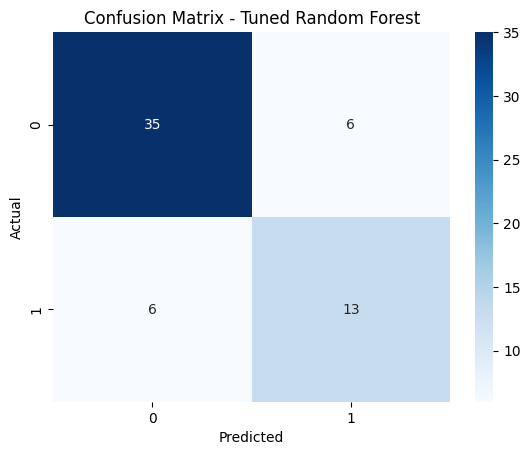

In [19]:
# Confusion Matrix for the tuned model
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()